# Titanic - Exploratory Data Analysis


**Methodology note:** The train/validation split is performed before any exploratory analysis. From that point onward, **all EDA is conducted on `train_df` only**, while `val_df` remains untouched until final evaluation.

This approach keeps the validation set genuinely unseen and ensures that preprocessing and feature-engineering decisions are based only on the training data.

**Goal of this notebook:** understand the dataset, identify relevant patterns and data-quality issues, and use those findings to justify the preprocessing and feature-engineering choices implemented later in `src/preprocess.py`.


## 1. Setup and Data Loading

The dataset is downloaded and loaded using the reusable utilities implemented in `src/data.py`.  
A reproducible stratified train/validation split is created immediately after loading the data.

In [102]:
#imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data import (
    TARGET,
    download_titanic,
    load_train_csv,
    split_train_val,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_DIR.mkdir(exist_ok=True)

In [94]:
# Download and load Kaggle's train.csv
csv_path = download_titanic()
full_df = load_train_csv(csv_path)

# Create a reproducible stratified train/validation split
train_df, val_df = split_train_val(full_df)

In [95]:
# Sanity check: verify split sizes and class proportions
print(f"Full dataset shape: {full_df.shape}")
print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")

print(f"\nTraining survival rate: {train_df[TARGET].mean():.3f}")
print(f"Validation survival rate: {val_df[TARGET].mean():.3f}")

Full dataset shape: (891, 12)
Training set shape: (712, 12)
Validation set shape: (179, 12)

Training survival rate: 0.383
Validation survival rate: 0.385


The stratified split preserves nearly identical survival rates in the training and validation sets (38.3% vs. 38.5%). This confirms that the validation set is representative of the target distribution while remaining fully held out from the exploratory analysis.


## 2. Dataset Overview

This section provides a first look at the training data structure, column types, summary statistics, and potential data-quality issues before deeper analysis.


In [96]:
# Inspect the first rows to understand the raw structure of the training data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,693,1,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
1,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
2,528,0,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
3,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
4,802,1,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S


In [97]:
# Summarize feature types, missingness, and cardinality
overview = pd.DataFrame({
    "dtype": train_df.dtypes,
    "missing_count": train_df.isna().sum(),
    "missing_pct": train_df.isna().mean().mul(100).round(1),
    "n_unique": train_df.nunique()
})

overview

,dtype,missing_count,missing_pct,n_unique
PassengerId,int64,0,0.0,712
Survived,int64,0,0.0,2
Pclass,int64,0,0.0,3
Name,object,0,0.0,712
Sex,object,0,0.0,2
Age,float64,137,19.2,85
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Ticket,object,0,0.0,571
Fare,float64,0,0.0,226


### Initial observations

- `PassengerId` and `Name` are unique for every training observation, while `Ticket` also has high cardinality. Their raw representations are therefore unlikely to be suitable model inputs without transformation.
- `Age` has substantial missingness (19.2%) and will require an appropriate imputation strategy.
- `Cabin` is missing for 77.5% of passengers. Rather than immediately discarding it, I will investigate whether its availability or deck information contains useful signal.
- `Embarked` has only two missing observations (0.3%), while `Sex`, `Pclass`, and `Embarked` have low cardinality and are natural candidates for categorical encoding.
- `SibSp` and `Parch` may contain useful information about family structure and will be explored further.

In [98]:
# Summarize the distributions of meaningful numerical features
numerical_summary_cols = [
    TARGET,
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

train_df[numerical_summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,712.0,0.383427,0.486563,0.00,0.0000,0.0000,1.0,1.0000
Pclass,712.0,2.308989,0.833563,1.00,2.0000,3.0000,3.0,3.0000
Age,575.0,29.807687,14.485211,0.42,21.0000,28.5000,39.0,80.0000
SibSp,712.0,0.492978,1.060720,0.00,0.0000,0.0000,1.0,8.0000
Parch,712.0,0.390449,0.838134,0.00,0.0000,0.0000,0.0,6.0000
Fare,712.0,31.819826,48.059104,0.00,7.8958,14.4542,31.0,512.3292


In [99]:
# Summarize the categorical features
train_df.describe(include="object").T

,count,unique,top,freq
Name,712,712,"Lam, Mr. Ali",1
Sex,712,2,male,459
Ticket,712,571,1601,6
Cabin,160,127,G6,4
Embarked,710,3,S,516


### Numerical summary - initial observations

- `Age` spans a wide range (0.42–80 years), with a mean (29.8) relatively close to the median (28.5).
- `Fare` appears strongly right-skewed: its mean (31.8) is more than twice its median (14.5), while the maximum fare (512.3) is far above the 75th percentile (31.0). Its distribution and potential outliers require further investigation.
- Both `SibSp` and `Parch` are concentrated at zero, suggesting that many passengers traveled without immediate family members represented by these variables. Their combined family structure may be more informative and will be explored later.
- Although `Pclass` is stored as an integer, it represents an ordinal passenger class rather than a continuous numerical measurement.

## 3. Target Distribution (Survived)

Before analyzing the predictors, we examine the distribution of the binary target variable, `Survived`. Understanding the class balance is important for both model training and the choice of evaluation metrics.

In [100]:
# Calculate class counts and proportions in the training set
target_summary = (
    train_df[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Did not survive", 1: "Survived"})
    .to_frame("count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(train_df) * 100
).round(1)

target_summary

,count,percentage
Survived,,
Did not survive,439,61.7
Survived,273,38.3


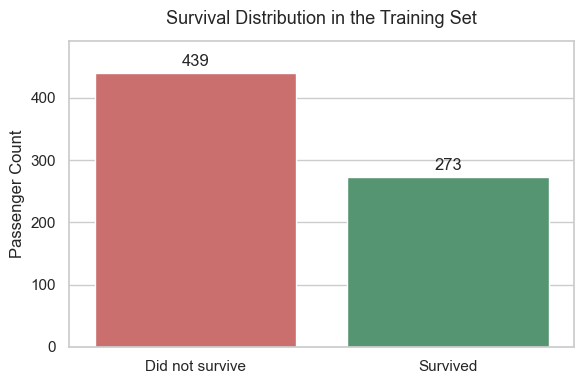

In [117]:
# Visualize the class distribution of the target variable
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=train_df,
    x=TARGET,
    hue=TARGET,
    palette={0: "#D95F5F", 1: "#4C9F70"},
    legend=False,
    ax=ax,
)

ax.set_title("Survival Distribution in the Training Set", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Passenger Count")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Did not survive", "Survived"])

# Add counts above the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add extra space above the tallest bar so labels stay inside the figure
ax.set_ylim(0, train_df[TARGET].value_counts().max() * 1.12)

fig.tight_layout()

fig.savefig(
    DOCS_DIR / "eda_target_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Key takeaway

The target is moderately imbalanced: 61.7% of passengers did not survive, while 38.3% survived.

A trivial majority-class classifier that predicts "did not survive" for every passenger would therefore achieve 61.7% accuracy. This provides a simple baseline that any useful predictive model should outperform.

The imbalance is moderate rather than severe, so no resampling or class weighting is applied at this stage. Model performance will instead be evaluated using metrics beyond accuracy, including precision, recall, F1-score, and ROC-AUC. Imbalance-handling techniques can be reconsidered later if the validation results indicate a need for them.

## 4. Missing Values and Data Quality

Missing values are examined not only by their frequency, but also by whether the missingness itself may be associated with the target.

In [10]:
# Summarize missing values in the training set
missing_summary = (
    train_df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(train_df) * 100
).round(1)

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
)

missing_summary

,missing_count,missing_pct
Cabin,552,77.5
Age,137,19.2
Embarked,2,0.3


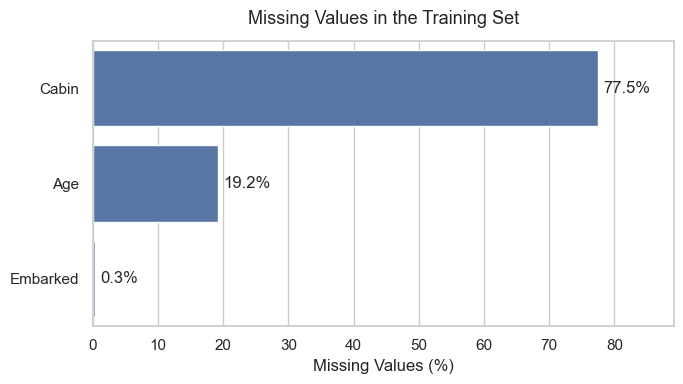

In [11]:
# Visualize the proportion of missing values by feature
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=missing_summary.reset_index(),
    x="missing_pct",
    y="index",
)

plt.title("Missing Values in the Training Set", fontsize=13, pad=12)
plt.xlabel("Missing Values (%)")
plt.ylabel("")

# Add percentage labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4)

ax.set_xlim(0, missing_summary["missing_pct"].max() * 1.15)

plt.tight_layout()
plt.show()

In [12]:
# Check whether recorded Cabin information is associated with survival
cabin_recorded_analysis = (
    train_df
    .assign(CabinRecorded=train_df["Cabin"].notna())
    .groupby("CabinRecorded")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

cabin_recorded_analysis["survival_rate"] = (
    cabin_recorded_analysis["survival_rate"] * 100
).round(1)

cabin_recorded_analysis

,count,survival_rate
CabinRecorded,,
False,552,29.2
True,160,70.0


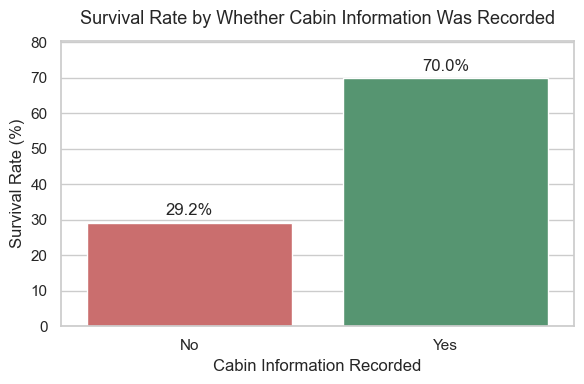

In [13]:
# Reuse the aggregated results for visualization
cabin_plot_df = cabin_recorded_analysis.reset_index()

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=cabin_plot_df,
    x="CabinRecorded",
    y="survival_rate",
    hue="CabinRecorded",
    palette={False: "#D95F5F", True: "#4C9F70"},
    legend=False
)

plt.title(
    "Survival Rate by Whether Cabin Information Was Recorded",
    fontsize=13,
    pad=12
)
plt.xlabel("Cabin Information Recorded")
plt.ylabel("Survival Rate (%)")
plt.xticks([0, 1], ["No", "Yes"])

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

# Leave enough space for the labels above the bars
ax.set_ylim(0, cabin_plot_df["survival_rate"].max() * 1.15)

plt.tight_layout()
plt.show()

In [14]:
# Check whether missing Age values are associated with survival
age_missing_analysis = (
    train_df
    .assign(AgeMissing=train_df["Age"].isna())
    .groupby("AgeMissing")[TARGET]
    .agg(["count", "mean"])
    .rename(columns={"mean": "survival_rate"})
)

age_missing_analysis["survival_rate"] = (
    age_missing_analysis["survival_rate"] * 100
).round(1)

age_missing_analysis

,count,survival_rate
AgeMissing,,
False,575,40.5
True,137,29.2


In [15]:
# Check whether Cabin information availability differs by passenger class
cabin_by_class = pd.crosstab(
    train_df["Pclass"],
    train_df["Cabin"].notna(),
    normalize="index"
).mul(100).round(1)

cabin_by_class.columns = ["Cabin not recorded", "Cabin recorded"]

cabin_by_class

,Cabin not recorded,Cabin recorded
Pclass,,
1,20.5,79.5
2,90.0,10.0
3,97.7,2.3


In [16]:
# Compare survival rates by passenger class and Cabin information availability
cabin_class_survival = (
    train_df
    .assign(CabinRecorded=train_df["Cabin"].notna())
    .groupby(["Pclass", "CabinRecorded"])[TARGET]
    .agg(["count", "mean"])
    .rename(columns={"mean": "survival_rate"})
)

cabin_class_survival["survival_rate"] = (
    cabin_class_survival["survival_rate"] * 100
).round(1)

cabin_class_survival

count  survival_rate
Pclass CabinRecorded                      
1      False             35           45.7
       True             136           69.9
2      False            135           40.7
       True              15           80.0
3      False            382           23.6
       True               9           55.6

### Cabin missingness and passenger class

Cabin information is strongly associated with passenger class: it is recorded for 79.5% of first-class passengers, but only 10.0% and 2.3% of second- and third-class passengers.

Survival is still higher among passengers with recorded cabin information within each class, suggesting that `CabinRecorded` may contain additional signal beyond `Pclass`. This should be interpreted cautiously because the recorded-cabin groups in classes 2 and 3 are small.

### Key takeaways

- Missingness is concentrated in `Cabin` (77.5%), `Age` (19.2%), and `Embarked` (0.3%).
- `CabinRecorded` shows a strong association with survival, but it is also strongly related to `Pclass`. The within-class analysis suggests it may still contain additional predictive information, although small subgroup sizes make this conclusion tentative.
- `Age` missingness is also associated with survival, but the difference is more moderate. Whether an explicit `AgeMissing` indicator is useful will be reconsidered after examining age itself.
- `Embarked` has very little missingness, so a simple imputation strategy is likely to be sufficient.

## 5. Feature Analysis

This section explores the main predictive features and their relationship with survival. Numerical and categorical variables are examined separately, with particular attention to patterns that may motivate preprocessing or feature engineering decisions.

### 5.1 Sex and Survival

In [17]:
# Compare group sizes and survival rates across sex categories
sex_survival = (
    train_df
    .groupby("Sex")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

sex_survival["survival_rate"] = (
    sex_survival["survival_rate"] * 100
).round(1)

sex_survival

,count,survival_rate
Sex,,
female,253,74.3
male,459,18.5


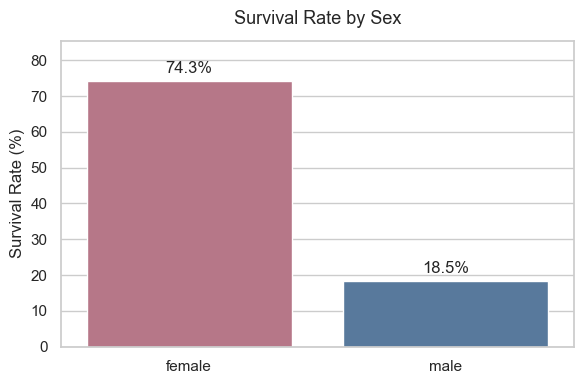

In [18]:
# Visualize survival rate across sex categories
sex_plot_df = sex_survival.reset_index()

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=sex_plot_df,
    x="Sex",
    y="survival_rate",
    hue="Sex",
    palette={"female": "#C06C84", "male": "#4C78A8"},
    legend=False
)

plt.title("Survival Rate by Sex", fontsize=13, pad=12)
plt.xlabel("")
plt.ylabel("Survival Rate (%)")

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, sex_plot_df["survival_rate"].max() * 1.15)

plt.tight_layout()
plt.show()

**Observation:** Survival rates differ substantially by sex in the training data: 74.3% for females compared with 18.5% for males. This suggests that `Sex` is likely to carry strong predictive signal and should be retained for later modeling.

### 5.2 Passenger Class and Survival

In [19]:
# Compare group sizes and survival rates across passenger classes
pclass_survival = (
    train_df
    .groupby("Pclass")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

pclass_survival["survival_rate"] = (
    pclass_survival["survival_rate"] * 100
).round(1)

pclass_survival

,count,survival_rate
Pclass,,
1,171,64.9
2,150,44.7
3,391,24.3


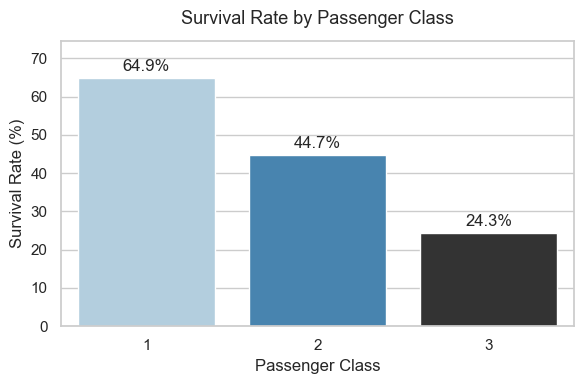

In [115]:
# Visualize survival rate across passenger classes
pclass_plot_df = pclass_survival.reset_index()

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=pclass_plot_df,
    x="Pclass",
    y="survival_rate",
    hue="Pclass",
    palette="Blues_d",
    legend=False,
    ax=ax,
)

ax.set_title("Survival Rate by Passenger Class", fontsize=13, pad=12)
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate (%)")

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, pclass_plot_df["survival_rate"].max() * 1.15)

fig.tight_layout()

fig.savefig(
    DOCS_DIR / "eda_pclass_survival.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

**Observation:** Survival rates decrease consistently from first to third class (64.9%, 44.7%, and 24.3%). This suggests that `Pclass` carries substantial predictive information and should be retained for modeling.

### 5.3 Age and Survival

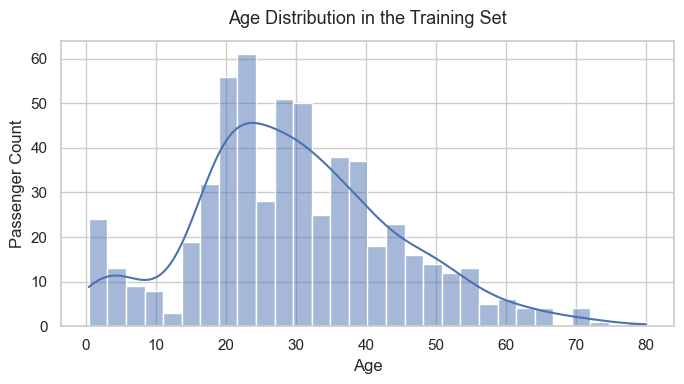

In [21]:
# Examine the overall age distribution
plt.figure(figsize=(7, 4))

sns.histplot(
    data=train_df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution in the Training Set", fontsize=13, pad=12)
plt.xlabel("Age")
plt.ylabel("Passenger Count")

plt.tight_layout()
plt.show()

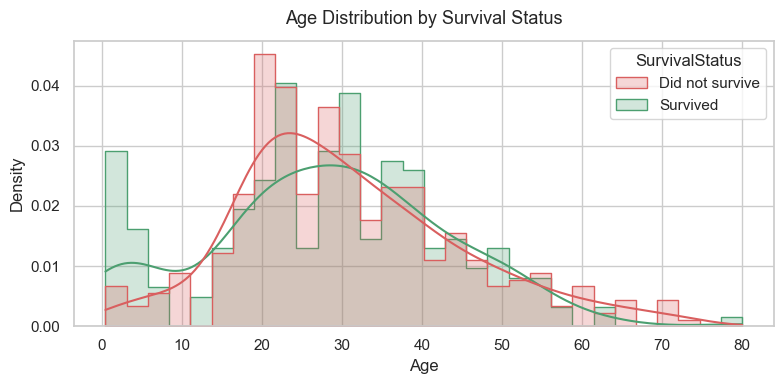

In [22]:
# Compare age distributions between survival groups
age_plot_df = train_df.copy()

# Use readable labels for visualization only
age_plot_df["SurvivalStatus"] = age_plot_df[TARGET].map({
    0: "Did not survive",
    1: "Survived"
})

plt.figure(figsize=(8, 4))

sns.histplot(
    data=age_plot_df,
    x="Age",
    hue="SurvivalStatus",
    hue_order=["Did not survive", "Survived"],
    palette={
        "Did not survive": "#D95F5F",
        "Survived": "#4C9F70"
    },
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution by Survival Status", fontsize=13, pad=12)
plt.xlabel("Age")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [23]:
# Compare age summary statistics by survival status
age_by_survival = (
    train_df
    .groupby(TARGET)["Age"]
    .agg(["count", "mean", "median"])
    .round(1)
)

age_by_survival

,count,mean,median
Survived,,,
0,342,30.8,28.2
1,233,28.3,29.0


In [24]:
# Create temporary age groups for exploratory analysis only
age_analysis = train_df.dropna(subset=["Age"]).copy()

age_analysis["AgeGroup"] = pd.cut(
    age_analysis["Age"],
    bins=[0, 12, 18, 30, 45, 60, float("inf")],
    labels=["0–12", "13–18", "19–30", "31–45", "46–60", "60+"],
    right=True
)

age_group_survival = (
    age_analysis
    .groupby("AgeGroup", observed=True)[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

age_group_survival["survival_rate"] = (
    age_group_survival["survival_rate"] * 100
).round(1)

age_group_survival

,count,survival_rate
AgeGroup,,
0–12,55,60.0
13–18,53,41.5
19–30,215,34.4
31–45,170,44.1
46–60,66,39.4
60+,16,18.8


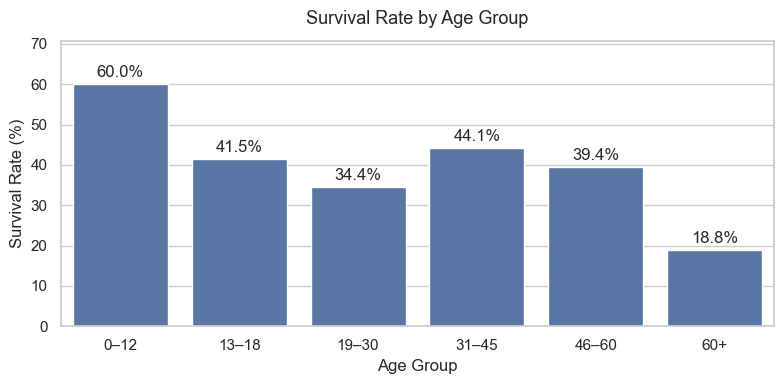

In [25]:
# Visualize survival rate across exploratory age groups
age_group_plot_df = age_group_survival.reset_index()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=age_group_plot_df,
    x="AgeGroup",
    y="survival_rate"
)

plt.title("Survival Rate by Age Group", fontsize=13, pad=12)
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

# Add survival-rate labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, age_group_plot_df["survival_rate"].max() * 1.18)

plt.tight_layout()
plt.show()

**Observation:** Survival does not vary monotonically with age. Children aged 0–12 show a relatively high observed survival rate, while the oldest group has the lowest rate. The 60+ estimate should be interpreted cautiously because this subgroup contains only 16 passengers.

The pattern suggests that the relationship between age and survival may be non-linear. The age groups used here are exploratory only and are not yet a modeling decision.

### 5.4 Fare and Survival

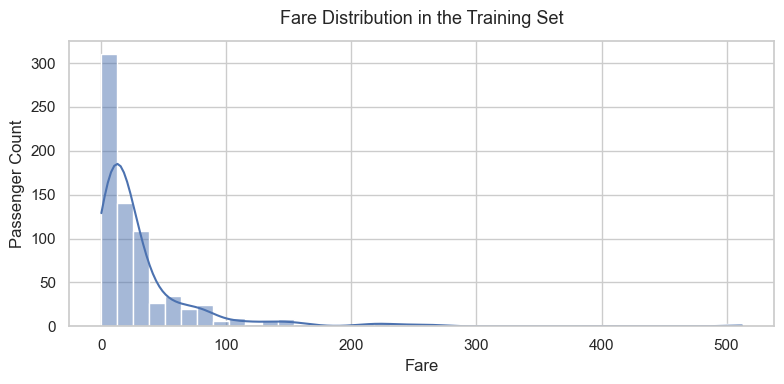

In [116]:
# Examine the overall fare distribution
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=train_df,
    x="Fare",
    bins=40,
    kde=True,
    ax=ax,
)

ax.set_title("Fare Distribution in the Training Set", fontsize=13, pad=12)
ax.set_xlabel("Fare")
ax.set_ylabel("Passenger Count")

fig.tight_layout()

fig.savefig(
    DOCS_DIR / "eda_fare_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [27]:
# Compare fare summary statistics by survival status
fare_by_survival = (
    train_df
    .groupby(TARGET)["Fare"]
    .agg(["count", "mean", "median"])
    .round(2)
)

fare_by_survival

,count,mean,median
Survived,,,
0,439,21.39,10.5
1,273,48.60,26.0


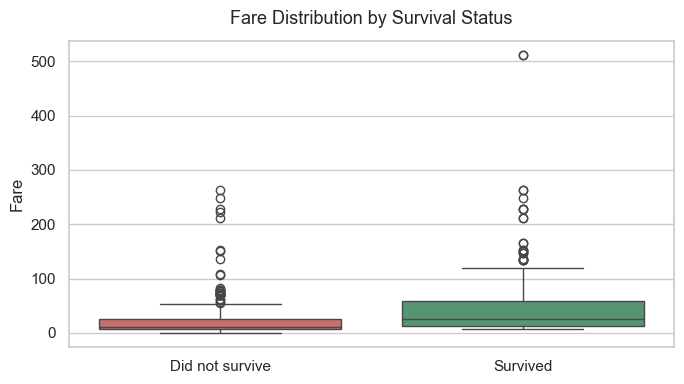

In [28]:
# Compare Fare distributions between survival groups
fare_plot_df = train_df.copy()

fare_plot_df["SurvivalStatus"] = fare_plot_df[TARGET].map({
    0: "Did not survive",
    1: "Survived"
})

plt.figure(figsize=(7, 4))

ax = sns.boxplot(
    data=fare_plot_df,
    x="SurvivalStatus",
    y="Fare",
    hue="SurvivalStatus",
    order=["Did not survive", "Survived"],
    palette={
        "Did not survive": "#D95F5F",
        "Survived": "#4C9F70"
    },
    legend=False
)

plt.title("Fare Distribution by Survival Status", fontsize=13, pad=12)
plt.xlabel("")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

In [29]:
# Examine how Fare varies across passenger classes
fare_by_class = (
    train_df
    .groupby("Pclass")["Fare"]
    .agg(
        count="size",
        mean="mean",
        median="median"
    )
    .round(2)
)

fare_by_class

,count,mean,median
Pclass,,,
1,171,83.00,57.98
2,150,20.81,14.50
3,391,13.66,8.05


**Observation:** `Fare` is strongly right-skewed and is substantially higher among survivors in both mean and median terms. It is also strongly associated with `Pclass`, suggesting that part of its apparent relationship with survival may reflect passenger class.

Because of the strong skew, a transformation such as `log1p(Fare)` may be worth considering during preprocessing, while retaining the raw signal for model comparison.

### 5.5 Family-related Features

In [30]:
# Compare survival rates across numbers of siblings/spouses aboard
sibsp_survival = (
    train_df
    .groupby("SibSp")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

sibsp_survival["survival_rate"] = (
    sibsp_survival["survival_rate"] * 100
).round(1)

sibsp_survival

,count,survival_rate
SibSp,,
0,494,34.4
1,164,53.7
2,21,52.4
3,10,10.0
4,15,20.0
5,3,0.0
8,5,0.0


In [31]:
# Compare survival rates across numbers of parents/children aboard
parch_survival = (
    train_df
    .groupby("Parch")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

parch_survival["survival_rate"] = (
    parch_survival["survival_rate"] * 100
).round(1)

parch_survival

,count,survival_rate
Parch,,
0,542,34.1
1,94,54.3
2,61,54.1
3,5,60.0
4,4,0.0
5,5,20.0
6,1,0.0


#### Family size

In [32]:
# Combine family-related counts into a single exploratory feature
family_analysis = train_df.copy()

family_analysis["FamilySize"] = (
    family_analysis["SibSp"]
    + family_analysis["Parch"]
    + 1
)

family_size_survival = (
    family_analysis
    .groupby("FamilySize")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

family_size_survival["survival_rate"] = (
    family_size_survival["survival_rate"] * 100
).round(1)

family_size_survival

,count,survival_rate
FamilySize,,
1,434,30.0
2,129,55.0
3,77,62.3
4,22,72.7
5,14,21.4
6,16,6.2
7,11,36.4
8,4,0.0
11,5,0.0


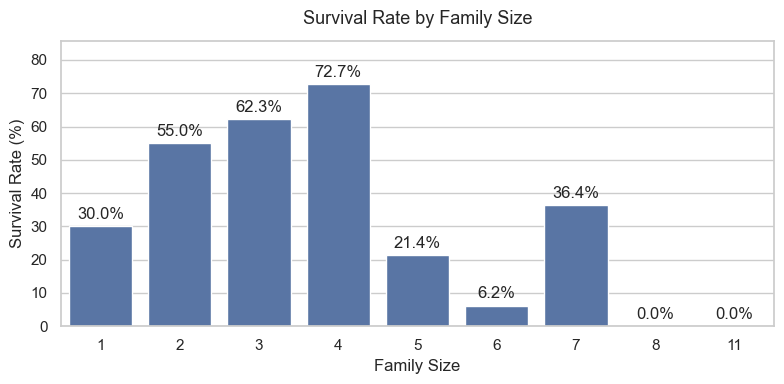

In [33]:
# Visualize survival rate across family sizes
family_size_plot_df = family_size_survival.reset_index()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=family_size_plot_df,
    x="FamilySize",
    y="survival_rate"
)

plt.title("Survival Rate by Family Size", fontsize=13, pad=12)
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

# Add survival-rate labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, family_size_plot_df["survival_rate"].max() * 1.18)

plt.tight_layout()
plt.show()

In [34]:
# Examine whether traveling alone is associated with survival
family_analysis["IsAlone"] = family_analysis["FamilySize"].eq(1)

alone_survival = (
    family_analysis
    .groupby("IsAlone")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

alone_survival["survival_rate"] = (
    alone_survival["survival_rate"] * 100
).round(1)

alone_survival

,count,survival_rate
IsAlone,,
False,278,51.4
True,434,30.0


**Observation:** Traveling alone is associated with a substantially lower observed survival rate (30.0%) compared with traveling with at least one family member (51.4%).

`FamilySize` also shows a non-linear pattern, with small families appearing to have higher survival rates than passengers traveling alone. Very large family-size groups are small, so their survival estimates should be interpreted cautiously.

These patterns suggest that `FamilySize` and `IsAlone` are reasonable candidates for feature engineering.

### 5.6 Embarked and Survival

In [35]:
# Compare group sizes and survival rates across embarkation ports
embarked_survival = (
    train_df
    .groupby("Embarked", dropna=False)[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

embarked_survival["survival_rate"] = (
    embarked_survival["survival_rate"] * 100
).round(1)

embarked_survival

,count,survival_rate
Embarked,,
C,139,56.1
Q,55,43.6
S,516,32.8
NaN,2,100.0


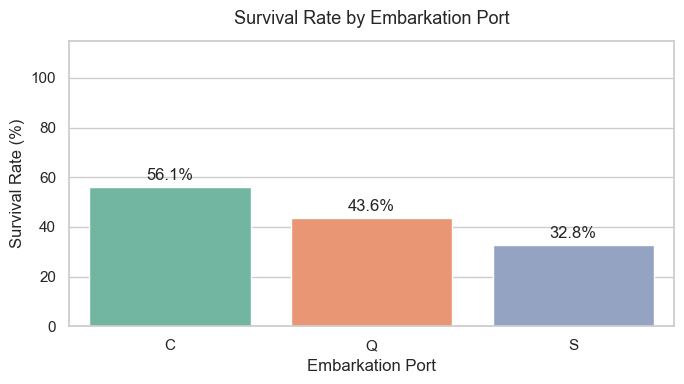

In [36]:
# Visualize survival rate across embarkation ports
embarked_plot_df = (
    embarked_survival
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=embarked_plot_df,
    x="Embarked",
    y="survival_rate",
    hue="Embarked",
    palette="Set2",
    legend=False
)

plt.title("Survival Rate by Embarkation Port", fontsize=13, pad=12)
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, embarked_plot_df["survival_rate"].max() * 1.15)

plt.tight_layout()
plt.show()

**Observation:** Survival rates vary across embarkation ports, with the highest observed rate among passengers embarking at `C` and the lowest at `S`.

The two missing `Embarked` values are too few to interpret meaningfully. Given the very low missingness and the dominance of `S` as the most frequent category, simple mode imputation is a reasonable candidate for preprocessing.

### 5.7 High-cardinality Text Features

#### Name

In [37]:
# Extract passenger titles from Name for exploratory analysis
name_analysis = train_df.copy()

name_analysis["Title"] = (
    name_analysis["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

title_summary = (
    name_analysis
    .groupby("Title")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
    .sort_values("count", ascending=False)
)

title_summary["survival_rate"] = (
    title_summary["survival_rate"] * 100
).round(1)

title_summary

,count,survival_rate
Title,,
Mr,412,15.3
Miss,141,70.2
Mrs,107,78.5
Master,31,54.8
Dr,6,50.0
Rev,5,0.0
Col,2,50.0
Mlle,2,100.0
Don,1,0.0


In [38]:
# Group rare titles to reduce sparsity in the exploratory view
common_titles = ["Mr", "Miss", "Mrs", "Master"]

name_analysis["TitleGrouped"] = name_analysis["Title"].where(
    name_analysis["Title"].isin(common_titles),
    "Rare"
)

title_grouped_summary = (
    name_analysis
    .groupby("TitleGrouped")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
    .sort_values("count", ascending=False)
)

title_grouped_summary["survival_rate"] = (
    title_grouped_summary["survival_rate"] * 100
).round(1)

title_grouped_summary

,count,survival_rate
TitleGrouped,,
Mr,412,15.3
Miss,141,70.2
Mrs,107,78.5
Master,31,54.8
Rare,21,47.6


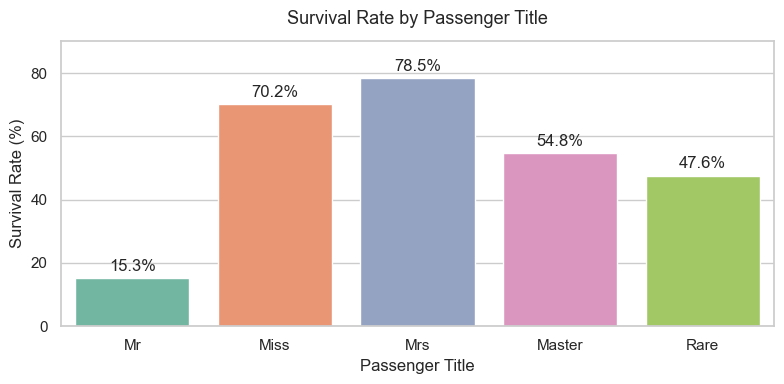

In [39]:
# Visualize survival rate across grouped passenger titles
title_plot_df = title_grouped_summary.reset_index()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=title_plot_df,
    x="TitleGrouped",
    y="survival_rate",
    hue="TitleGrouped",
    palette="Set2",
    legend=False
)

plt.title("Survival Rate by Passenger Title", fontsize=13, pad=12)
plt.xlabel("Passenger Title")
plt.ylabel("Survival Rate (%)")

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, title_plot_df["survival_rate"].max() * 1.15)

plt.tight_layout()
plt.show()

**Observation:** Grouped passenger titles show clear differences in observed survival rates. Extracting `Title` from `Name` substantially reduces cardinality while preserving potentially useful predictive information, making it a strong feature-engineering candidate.

#### Ticket

In [40]:
# Count how many passengers share each ticket
ticket_analysis = train_df.copy()

ticket_analysis["TicketGroupSize"] = (
    ticket_analysis
    .groupby("Ticket")["Ticket"]
    .transform("size")
)

ticket_group_summary = (
    ticket_analysis
    .groupby("TicketGroupSize")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
)

ticket_group_summary["survival_rate"] = (
    ticket_group_summary["survival_rate"] * 100
).round(1)

ticket_group_summary

,count,survival_rate
TicketGroupSize,,
1,476,31.7
2,138,62.3
3,42,59.5
4,24,25.0
5,20,0.0
6,12,41.7


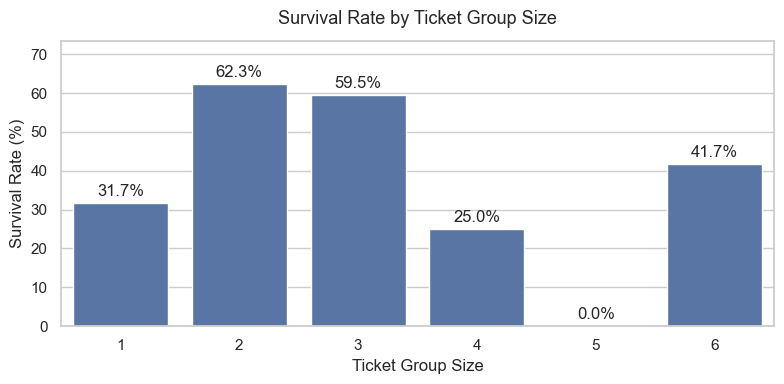

In [41]:
# Visualize survival rate by ticket group size
ticket_group_plot_df = ticket_group_summary.reset_index()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=ticket_group_plot_df,
    x="TicketGroupSize",
    y="survival_rate"
)

plt.title("Survival Rate by Ticket Group Size", fontsize=13, pad=12)
plt.xlabel("Ticket Group Size")
plt.ylabel("Survival Rate (%)")

# Add survival-rate labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_ylim(0, ticket_group_plot_df["survival_rate"].max() * 1.18)

plt.tight_layout()
plt.show()

**Observation:** `TicketGroupSize` shows a relationship with survival, suggesting that shared tickets may capture group-travel information.

However, unlike the other engineered features, `TicketGroupSize` depends on which passengers are present in the input dataset rather than solely on the passenger's own attributes. It is therefore not reliably reproducible for arbitrary inference inputs and will not be included in the preprocessing pipeline.

#### Cabin

In [42]:
# Extract deck information from recorded Cabin values
cabin_analysis = train_df.copy()

cabin_analysis["Deck"] = (
    cabin_analysis["Cabin"]
    .str[0]
    .fillna("Unknown")
)

deck_summary = (
    cabin_analysis
    .groupby("Deck")[TARGET]
    .agg(
        count="size",
        survival_rate="mean"
    )
    .sort_values("count", ascending=False)
)

deck_summary["survival_rate"] = (
    deck_summary["survival_rate"] * 100
).round(1)

deck_summary

,count,survival_rate
Deck,,
Unknown,552,29.2
C,41,68.3
B,34,73.5
E,29,75.9
D,26,80.8
A,14,42.9
F,11,72.7
G,4,50.0
T,1,0.0


**Observation:** Recorded deck information shows meaningful variation in observed survival rates, but several deck categories contain very few passengers. `Deck` may therefore provide additional signal, although it is less stable than the simpler `CabinRecorded` indicator.

### 5.8 Feature Relationships and Potential Redundancy

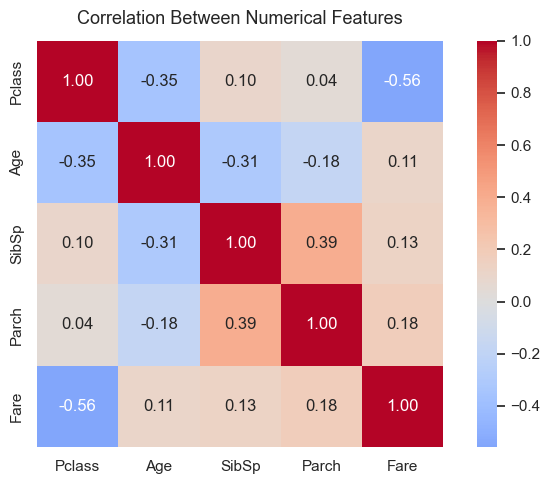

In [43]:
# Inspect correlations among numerical predictor features
corr_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

corr_matrix = train_df[corr_features].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Between Numerical Features", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

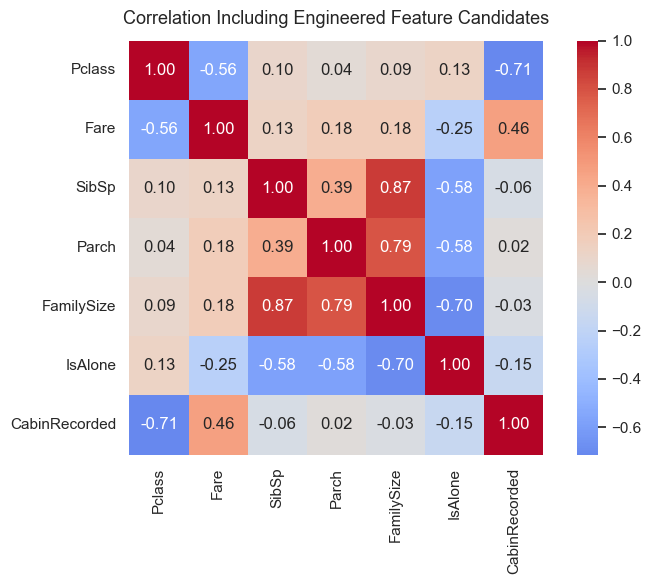

In [44]:
# Inspect correlations after adding exploratory engineered features
engineered_analysis = train_df.copy()

engineered_analysis["FamilySize"] = (
    engineered_analysis["SibSp"]
    + engineered_analysis["Parch"]
    + 1
)

engineered_analysis["IsAlone"] = (
    engineered_analysis["FamilySize"] == 1
).astype(int)

engineered_analysis["CabinRecorded"] = (
    engineered_analysis["Cabin"].notna()
).astype(int)

engineered_corr = engineered_analysis[
    [
        "Pclass",
        "Fare",
        "SibSp",
        "Parch",
        "FamilySize",
        "IsAlone",
        "CabinRecorded"
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    engineered_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Including Engineered Feature Candidates", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

**Observation:** Several engineered features are strongly correlated with the variables they are derived from, particularly `FamilySize` with `SibSp`/`Parch` and `IsAlone` with `FamilySize`. `CabinRecorded` is also strongly associated with `Pclass`, reinforcing that some engineered features may partly capture information already present elsewhere.

In [45]:
# Inspect linear correlations between numerical features and the target
target_correlations = (
    train_df[
        ["Pclass", "Age", "SibSp", "Parch", "Fare", TARGET]
    ]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

target_correlations

Pclass   -0.348007
Fare      0.275499
Age      -0.084268
Parch     0.084178
SibSp    -0.026115
Name: Survived, dtype: float64

**Observation:** Among the numerical predictors, `Pclass` shows the strongest linear association with survival (`r = -0.35`), followed by `Fare` (`r = 0.28`). `Age`, `Parch`, and `SibSp` show only weak linear correlations with the target.

These values summarize linear relationships only and should not be interpreted as feature importance, especially because several predictors show non-linear patterns in the earlier analysis.

### Key Takeaways

- `Sex` and `Pclass` show strong associations with survival and appear to be important predictors.
- `Age` contains useful signal, but its relationship with survival appears non-linear and should be interpreted alongside its missingness.
- `Fare` is strongly right-skewed and associated with both survival and `Pclass`, so a transformation may be worth considering.
- Family-related variables suggest that `FamilySize` and `IsAlone` may capture useful structure, although they are naturally correlated with `SibSp` and `Parch`.
- High-cardinality raw features such as `Name`, `Ticket`, and `Cabin` are unlikely to be useful directly. Engineered features such as `Title` and `CabinRecorded` may preserve useful signal, while `TicketGroupSize`, although informative in the EDA, is excluded from the final pipeline because it is not reliably reproducible for arbitrary inference inputs.
- Several engineered features are correlated with their source variables, so the final preprocessing pipeline should avoid unnecessary redundancy.

## 6. EDA Conclusions and Preprocessing Plan

The exploratory analysis identified several useful patterns, data-quality considerations, and feature-engineering opportunities. This section summarizes the evidence gathered above and translates it into the preprocessing plan used by the modeling pipeline.

These decisions are based only on `train_df` and may be revisited if validation results suggest that a simpler or alternative representation performs better.

In [46]:
preprocessing_plan = pd.DataFrame([
    {
        "Feature": "PassengerId",
        "EDA finding": "Unique identifier with no intrinsic passenger information",
        "Planned action": "Drop"
    },
    {
        "Feature": "Sex",
        "EDA finding": "Low-cardinality categorical feature with strong association with survival",
        "Planned action": "One-hot encode"
    },
    {
        "Feature": "Pclass",
        "EDA finding": "Ordinal passenger class with clear monotonic survival differences",
        "Planned action": "Retain as ordinal numeric feature"
    },
    {
        "Feature": "Age",
        "EDA finding": "19.2% missing; non-linear relationship with survival; missingness itself shows signal",
        "Planned action": "Median imputation + AgeMissing indicator + scaling"
    },
    {
        "Feature": "Fare",
        "EDA finding": "Strongly right-skewed with extreme values; associated with survival and Pclass",
        "Planned action": "Apply log1p transformation + scaling"
    },
    {
        "Feature": "Embarked",
        "EDA finding": "Low-cardinality categorical feature with only two missing values",
        "Planned action": "Mode imputation + one-hot encoding"
    },
    {
        "Feature": "Name",
        "EDA finding": "Raw values are unique, but extracted titles show clear survival differences",
        "Planned action": "Extract grouped Title + one-hot encode; drop raw Name"
    },
    {
        "Feature": "SibSp / Parch",
        "EDA finding": "Combined family structure is more informative than either feature alone",
        "Planned action": "Engineer FamilySize and IsAlone; drop raw SibSp and Parch"
    },
    {
        "Feature": "Cabin",
        "EDA finding": "77.5% missing; recording status shows strong association with survival",
        "Planned action": "Engineer CabinRecorded; drop raw Cabin"
    },
    {
        "Feature": "Ticket",
        "EDA finding": "High cardinality; TicketGroupSize is dataset-dependent at inference time",
        "Planned action": "Drop raw Ticket; exclude TicketGroupSize"
    },
])
preprocessing_plan 

,Feature,EDA finding,Planned action
0,PassengerId,Unique identifier with no intrinsic passenger ...,Drop
1,Sex,Low-cardinality categorical feature with stron...,One-hot encode
2,Pclass,Ordinal passenger class with clear monotonic s...,Retain as ordinal numeric feature
3,Age,19.2% missing; non-linear relationship with su...,Median imputation + AgeMissing indicator + sca...
4,Fare,Strongly right-skewed with extreme values; ass...,Apply log1p transformation + scaling
5,Embarked,Low-cardinality categorical feature with only ...,Mode imputation + one-hot encoding
6,Name,"Raw values are unique, but extracted titles sh...",Extract grouped Title + one-hot encode; drop r...
7,SibSp / Parch,Combined family structure is more informative ...,Engineer FamilySize and IsAlone; drop raw SibS...
8,Cabin,77.5% missing; recording status shows strong a...,Engineer CabinRecorded; drop raw Cabin
9,Ticket,High cardinality; TicketGroupSize is dataset-d...,Drop raw Ticket; exclude TicketGroupSize


### Final feature groups for preprocessing

Based on the EDA above, the preprocessing pipeline will use the following feature groups.

In [47]:
NUMERICAL_FEATURES = [
    "Pclass",
    "Age",
    "Fare",
    "FamilySize",
]

BINARY_FEATURES = [
    "AgeMissing",
    "IsAlone",
    "CabinRecorded",
]

CATEGORICAL_FEATURES = [
    "Sex",
    "Embarked",
    "TitleGrouped",
]

`PassengerId`, raw `Name`, raw `Ticket`, raw `Cabin`, `SibSp`, and `Parch` are excluded after the engineered features above are created.

In [48]:
CONTINUOUS_FEATURES = [
    "Age",
    "Fare",
    "FamilySize",
]

ORDINAL_FEATURES = [
    "Pclass",
]

BINARY_FEATURES = [
    "AgeMissing",
    "IsAlone",
    "CabinRecorded",
]

CATEGORICAL_FEATURES = [
    "Sex",
    "Embarked",
    "TitleGrouped",
]

Raw `PassengerId`, `Name`, `Ticket`, `Cabin`, `SibSp`, and `Parch` are excluded after the engineered features above are created.